In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing  import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [59]:
# Q1. Data Loading & Understanding
# a) Load the dataset into Python.
df = pd.read_csv('/content/loan_approval - loan_approval.csv')

In [3]:
# b) Display the first 5 rows.
print(df.head())

              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  


In [4]:
# c) Check the shape of the dataset.
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 2000, Columns: 8


In [5]:
# d) Display the data types of each column.
print("\n--- Data types ---")
print(df.dtypes)


--- Data types ---
name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object


In [6]:
# Q2. Data Cleaning
# a) Check for missing values in the dataset
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64


In [7]:
# b) Handle missing values appropriately.
for col in df.columns:
    if df[col].dtype in ["int64", "float64"]:
        df[col].fillna(df[col].median(), inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
# c) Identify categorical columns present in the dataset.
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("\n--- Categorical Columns ---")
print(categorical_cols)


--- Categorical Columns ---
['name', 'city']


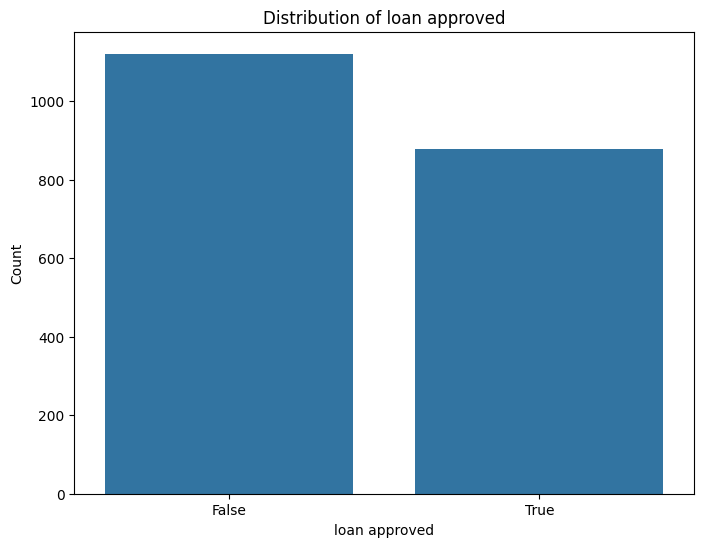

In [15]:
#Q3. Exploratory Data Analysis (EDA)
# a) Plot the distribution of the target variable.
# Assuming the target variable is named 'loan_approved' (change to match your dataset)
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='loan_approved')
plt.title('Distribution of loan approved')
plt.xlabel('loan approved')
plt.ylabel('Count')
plt.show()



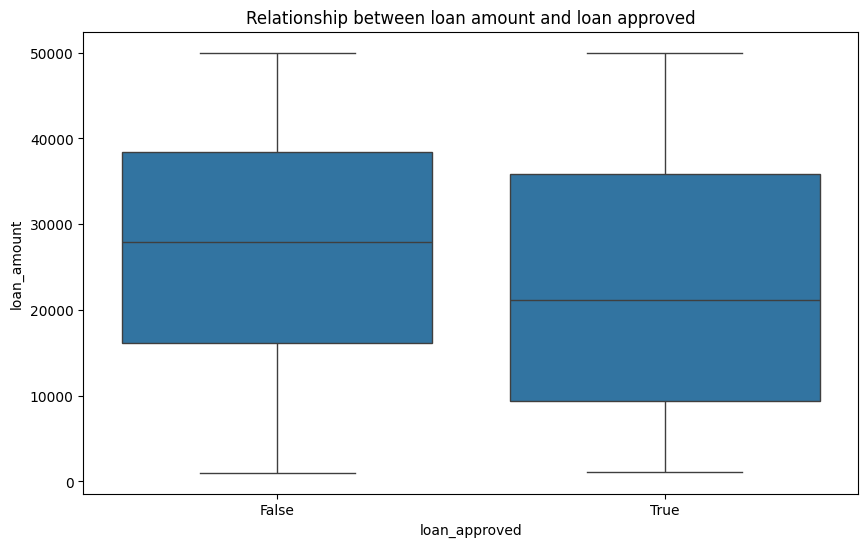

In [16]:
# b) Analyze the relationship between one numerical feature and the target variable.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='loan_approved', y='loan_amount')
plt.title('Relationship between loan amount and loan approved')
plt.show()


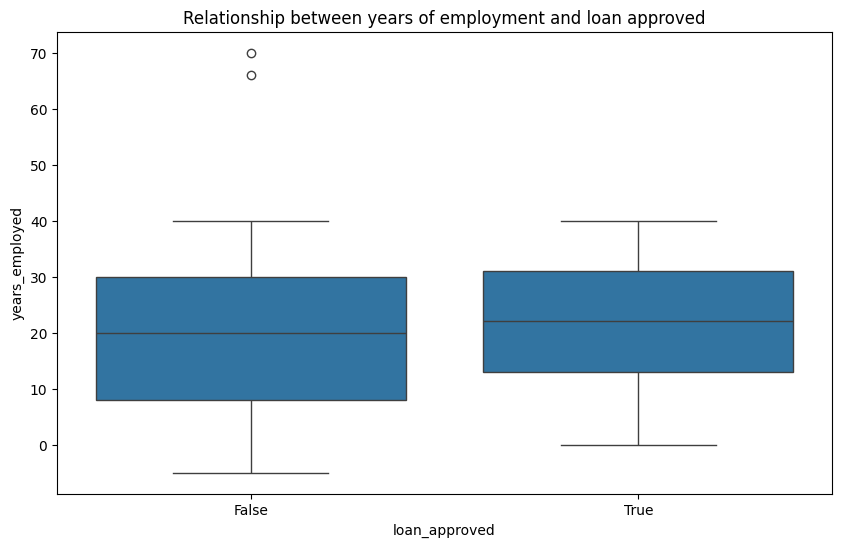

In [19]:
# c) Analyze the relationship between Years of Employment and the target variable.
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='loan_approved', y='years_employed')
plt.title('Relationship between years of employment and loan approved')
plt.show()



In [27]:
# Q4. Outlier Detection and Treatment
# a) Detect outliers in numerical columns using the IQR method.
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Ensure target variable or structural IDs aren't mistakenly capped
if 'loan_approved' in numerical_cols: numerical_cols.remove('loan_approved')

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bridge = Q1 - 1.5 * IQR
    upper_bridge = Q3 + 1.5 * IQR
#  b) Treat outliers using capping techniques
# Capping techniques
    df[col] = np.where(df[col] > upper_bridge, upper_bridge, df[col])
    df[col] = np.where(df[col] < lower_bridge, lower_bridge, df[col])
print("Outliers handled via IQR capping technique successfully.")


Outliers handled via IQR capping technique successfully.


In [58]:
# Q5. Convert Target & Categorical Variables to Numerical Format
print("\n--- feature encoding and column dropping ---")
if 'loan_approved' in df.columns:
    # Convert boolean 'loan_approved' column to integers (True=1, False=0)
    df['loan_approved'] = df['loan_approved'].astype(int)
    print("Target variable 'loan_approved' encoded successfully.")
else:
    print("Target variable 'loan_approved' not found in the dataset.")


--- feature encoding and column dropping ---
Target variable 'loan_approved' encoded successfully.


In [64]:
# Q6. Feature Selection and Data Splitting
# a) Separate independent variables (X) and dependent variable (y).
print(" feature selection ")
#X = df.drop(columns=['loan_approved'])
#y = df['loan_approved']

# Ensure y has no NaN values, and synchronize X
initial_rows_X = X.shape[0]
initial_rows_y = y.shape[0]

# Drop rows where y is NaN
y = y.dropna()

# Align X with the cleaned y by index
X = X.loc[y.index]

if initial_rows_y > y.shape[0]:
    print(f"Dropped {initial_rows_y - y.shape[0]} rows due to NaN values in the target variable 'y'.")

# Perform a quick check
print(f"y after cleaning has {y.isnull().sum()} NaN values.")

 feature selection 
y after cleaning has 0 NaN values.


In [37]:
# b) Split the dataset into training and testing sets (80/20 split recommended)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split executed into training and validation subsets.")

Data split executed into training and validation subsets.


In [60]:
print(f"Missing values in y_train: {y_train.isnull().sum()}")

Missing values in y_train: 1600


In [51]:
# --- Q7. Apply Feature Scaling ---
print("\n---  Apply feature scaling using StandardScaler ---")

# Drop categorical columns before scaling
X_train_numeric = X_train.drop(columns=categorical_cols)
X_test_numeric = X_test.drop(columns=categorical_cols)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)


---  Apply feature scaling using StandardScaler ---


In [66]:
from sklearn.linear_model import LogisticRegression

#--- Q8. Logistic Regression Model Building ---
print("\n--- Q8. Logistic Regression Model Building ---")

# a) Train a Logistic Regression model
# model = LogisticRegression(random_state=42)
# model.fit(X_train_scaled, y_train)


--- Q8. Logistic Regression Model Building ---
